In [2]:
import pandas as pd

# -------------------------------------------------------------
# 1. Your original classes
# -------------------------------------------------------------
class SeasonMapper:
    """Convert month → cropping season."""
    @staticmethod
    def month_to_season(df, month_col="Month"):
        df = df.copy()
        df["Season"] = None
        df.loc[df[month_col].between(6, 9), "Season"] = "Kharif"
        df.loc[(df[month_col] >= 10) | (df[month_col] <= 4), "Season"] = "Rabi"
        return df


class NDVIProcessor:
    """Convert monthly NDVI → seasonal NDVI."""
    @staticmethod
    def to_seasonal(ndvi_df):
        df = ndvi_df.copy()
        df["Year"] = df["Year"].astype(int)
        df["Month"] = df["Month"].astype(int)
        df = SeasonMapper.month_to_season(df, month_col="Month")
        seasonal = (
            df.groupby(["State", "Year", "Season"])["NDVI"]
              .mean()
              .reset_index()
              .rename(columns={"NDVI": "NDVI_SeasonalMean"})
        )
        return seasonal


class WeatherProcessor:
    @staticmethod
    def clean(weather_seasonal):
        df = weather_seasonal.copy()
        df["Year"] = df["Year"].astype(int)
        df["Season"] = df["Season"].astype(str)
        return df


class YieldProcessor:
    @staticmethod
    def clean(yield_df):
        df = yield_df.copy()
        df["Year"] = df["Year"].astype(int)
        df["Season"] = df["Season"].astype(str)
        return df


class SOCProcessor:
    @staticmethod
    def clean(soc_df):
        return soc_df.copy()


class DatasetMerger:
    def __init__(self, config=None):
        self.config = config

    def merge(self, weather_daily, weather_seasonal, ndvi, soc, yield_df):
        weather_seasonal = WeatherProcessor.clean(weather_seasonal)
        yield_df = YieldProcessor.clean(yield_df)
        soc = SOCProcessor.clean(soc)
        ndvi_seasonal = NDVIProcessor.to_seasonal(ndvi)

        merged = pd.merge(
            yield_df, weather_seasonal,
            on=["State", "Year", "Season"], how="left"
        )

        merged = pd.merge(
            merged, ndvi_seasonal,
            on=["State", "Year", "Season"], how="left"
        )

        merged = pd.merge(
            merged, soc,
            on="State", how="left"
        )

        merged = merged.dropna(subset=["Yield"])
        merged = merged.drop_duplicates()
        merged = merged.sort_values(["State", "Year", "Season"]).reset_index(drop=True)
        return merged


# -------------------------------------------------------------
# 2. Create sample input datasets
# -------------------------------------------------------------

# Example monthly NDVI data
ndvi_df = pd.DataFrame({
    "State": ["Punjab", "Punjab", "Punjab", "Punjab"],
    "Year": [2020, 2020, 2020, 2020],
    "Month": [6, 7, 10, 11],
    "NDVI": [0.30, 0.35, 0.25, 0.28]
})

# Seasonal weather data
weather_seasonal = pd.DataFrame({
    "State": ["Punjab", "Punjab"],
    "Year": [2020, 2020],
    "Season": ["Kharif", "Rabi"],
    "Rainfall": [500, 120],
    "Temp": [32, 18]
})

# SOC data (state-level)
soc = pd.DataFrame({
    "State": ["Punjab"],
    "SOC": [0.75]
})

# Yield data
yield_df = pd.DataFrame({
    "State": ["Punjab", "Punjab"],
    "Year": [2020, 2020],
    "Season": ["Kharif", "Rabi"],
    "Yield": [2200, 1800]
})

# -------------------------------------------------------------
# 3. Run the merger and display the result
# -------------------------------------------------------------
merger = DatasetMerger()

merged_df = merger.merge(
    weather_daily=None,       # Not used
    weather_seasonal=weather_seasonal,
    ndvi=ndvi_df,
    soc=soc,
    yield_df=yield_df
)

print("FINAL MERGED DATASET:")
print(merged_df)


FINAL MERGED DATASET:
    State  Year  Season  Yield  Rainfall  Temp  NDVI_SeasonalMean   SOC
0  Punjab  2020  Kharif   2200       500    32              0.325  0.75
1  Punjab  2020    Rabi   1800       120    18              0.265  0.75


In [2]:
!d:/Crop_yield_system/.jyp_env/Scripts/python.exe -m pip install pyyaml


  Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl.metadata (2.4 kB)
Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl (154 kB)



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
import os
import sys

# Path to project root (one folder above notebooks/)
project_root = os.path.abspath("..")

# Add project root to PYTHONPATH
if project_root not in sys.path:
    sys.path.append(project_root)

project_root


'd:\\Crop_yield_system'

In [13]:
import os
import sys
import pandas as pd
import yaml
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------
# Ensure project root is in PYTHONPATH
# ----------------------------------------
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

# Now safe to import src modules
from src.outlier_detection import OutlierHandler, ZScoreOutlierDetector, IQROutlierDetector

# Load config
config_path = os.path.join(project_root, "config.yaml")
with open(config_path, "r") as f:
    config = yaml.safe_load(f)


In [3]:
import pandas as pd
df = pd.read_csv("D:\\Crop_yield_system\\data\\Processed\\versions\\features_engineered_v12.csv")
df.head()


,State,Year,Area,Production,Yield,Season,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,...,NDVI_Rain_Hybrid,Yield_Lag1,NDVI_SeasonalMean_Lag1,PRECTOTCORR_Lag1,Yield_RollingMean_3,Yield_RollingStd_3,NDVI_RollingMean_3,NDVI_RollingStd_3,Rain_RollingMean_3,Rain_RollingStd_3
0,Chandigarh,2011,600,2725,4.54,Kharif,28.545820,32.636721,24.651230,1120.70,...,0.634253,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Chandigarh,2012,575,2590,4.50,Kharif,30.871885,35.985164,26.062869,761.14,...,0.505317,4.54,0.489154,1120.70,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,Chandigarh,2013,575,2600,4.52,Kharif,28.820410,32.811475,24.909918,1174.10,...,0.665548,4.50,0.456474,761.14,4.520000,0.020000,0.486627,0.028971,1018.646667,224.599983
3,Chandigarh,2015,550,2530,4.60,Kharif,29.421639,34.332951,24.787951,840.64,...,0.548063,4.52,0.514252,1174.10,4.540000,0.052915,0.486052,0.028913,925.293333,219.108719
4,Chandigarh,2016,550,2585,4.70,Kharif,30.185328,34.943361,25.512705,712.46,...,0.502269,4.60,0.487431,840.64,4.606667,0.090185,0.492582,0.019608,909.066667,238.305537


In [15]:
outlier_cfg = config["preprocessing"]["outliers"]
handler = OutlierHandler(outlier_cfg)
detector = handler.detector
columns = handler.columns


In [16]:
columns


['Yield (Tonne/Hectare)',
 'NDVI_SeasonalMean',
 'T2M',
 'T2M_MAX',
 'T2M_MIN',
 'PRECTOTCORR',
 'ALLSKY_SFC_SW_DWN',
 'RH2M',
 'WS2M',
 'Mean_SOC',
 'Median_SOC',
 'Min_SOC',
 'Max_SOC',
 'Std_SOC']

In [17]:
mask = detector.detect(df, columns)
df_outliers = df[~mask]
df_clean_preview = df[mask]


In [24]:
len(df_outliers), len(df)
df.columns

Index(['State', 'Year', 'Area (Hectare)', 'Production (Tonnes)',
       'Yield (Tonne/Hectare)', 'Season', 'T2M', 'T2M_MAX', 'T2M_MIN',
       'PRECTOTCORR', 'ALLSKY_SFC_SW_DWN', 'RH2M', 'WS2M', 'NDVI_SeasonalMean',
       'Mean_SOC', 'Median_SOC', 'Min_SOC', 'Max_SOC', 'Std_SOC'],
      dtype='object')

In [1]:
import pandas as pd

shap_df = pd.read_csv("D:\\Crop_yield_system\\data\\predictions\\shap_values.csv")

# Calculate importance
importance = shap_df.abs().mean().sort_values(ascending=False)

print(importance)


num__Yield_RollingMean_3    1.125815
num__Yield_RollingStd_3     0.499153
num__NDVI_RollingMean_3     0.191985
num__Rain_RollingMean_3     0.073228
num__WS2M                   0.062035
                              ...   
cat__State_CHANDIGARH       0.000000
cat__State_RAJASTHAN        0.000000
cat__Season_Rabi            0.000000
cat__NDVI_Level_low         0.000000
cat__NDVI_Level_moderate    0.000000
Length: 70, dtype: float64


In [4]:
print(shap_df.columns.tolist())


['num__Year', 'num__PRECTOTCORR', 'num__T2M', 'num__T2M_MAX', 'num__T2M_MIN', 'num__ALLSKY_SFC_SW_DWN', 'num__RH2M', 'num__WS2M', 'num__NDVI_SeasonalMean', 'num__Mean_SOC', 'num__Median_SOC', 'num__Min_SOC', 'num__Max_SOC', 'num__Std_SOC', 'num__NDVI_Rain_Ratio', 'num__NDVI_Temp_Interaction', 'num__Temp_NDVI', 'num__NDVI_mul_Rain', 'num__NDVI_div_Rain', 'num__Rain_div_NDVI', 'num__NDVI_plus_Rain', 'num__NDVI_minus_Rain', 'num__NDVI_anomaly', 'num__Rain_anomaly', 'num__Mean_SOC_NDVI_mul', 'num__Mean_SOC_NDVI_div', 'num__Mean_SOC_SOC_div_NDVI', 'num__Mean_SOC_NDVI_Hybrid', 'num__Mean_SOC_NDVI_Stress', 'num__Median_SOC_NDVI_mul', 'num__Median_SOC_NDVI_div', 'num__Median_SOC_SOC_div_NDVI', 'num__Median_SOC_NDVI_Hybrid', 'num__Median_SOC_NDVI_Stress', 'num__Min_SOC_NDVI_mul', 'num__Min_SOC_NDVI_div', 'num__Min_SOC_SOC_div_NDVI', 'num__Min_SOC_NDVI_Hybrid', 'num__Min_SOC_NDVI_Stress', 'num__Max_SOC_NDVI_mul', 'num__Max_SOC_NDVI_div', 'num__Max_SOC_SOC_div_NDVI', 'num__Max_SOC_NDVI_Hybrid', '

In [5]:
weather_cols = [
    c for c in shap_df.columns
    if any(k in c for k in [
        "T2M", "PRECTOTCORR", "RH2M", "WS2M"
    ])
]
radiation_cols = [
    c for c in shap_df.columns
    if "ALLSKY_SFC_SW_DWN" in c
]
ndvi_cols = [
    c for c in shap_df.columns
    if "NDVI" in c and "SOC" not in c
]
soc_cols = [
    c for c in shap_df.columns
    if "SOC" in c
]
temporal_cols = [
    c for c in shap_df.columns
    if "Yield_" in c or "Lag" in c or "Rolling" in c
]
def group_contribution(cols):
    return shap_df[cols].abs().mean().sum()

print("Weather:", group_contribution(weather_cols))
print("Radiation:", group_contribution(radiation_cols))
print("NDVI:", group_contribution(ndvi_cols))
print("Soil (SOC):", group_contribution(soc_cols))
print("Temporal:", group_contribution(temporal_cols))


Weather: 0.1093983696340525
Radiation: 0.001988078954715525
NDVI: 0.27997771828511314
Soil (SOC): 0.027486762044553657
Temporal: 1.9690311944089978


In [ ]:
row_2026 = shap_df.iloc[-1].sort_values(key=abs, ascending=False)
row_2026.head(8)

num__Yield_RollingMean_3     -1.332312
num__Yield_RollingStd_3       0.619552
num__NDVI_RollingMean_3       0.218446
num__Yield_Lag1              -0.067803
num__WS2M                    -0.066425
num__Rain_anomaly            -0.053756
num__NDVI_Temp_Interaction   -0.021919
num__NDVI_Rain_Hybrid        -0.017578
Name: 3, dtype: float64

: 

In [1]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

shap_df = pd.read_csv("D:\\Crop_yield_system\\data\\predictions\\shap_values.csv")
shap_df = shap_df.astype(float)

print(shap_df.shape)
print(shap_df.head())


d:\Crop_Yield_System\.venv\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


(4, 70)
   num__Year  num__PRECTOTCORR  num__T2M  num__T2M_MAX  num__T2M_MIN  \
0  -0.005505          0.022670 -0.015077     -0.002141     -0.008582   
1  -0.006561          0.021719 -0.017249     -0.003428     -0.014568   
2   0.000438          0.021290 -0.003039     -0.002813     -0.006668   
3  -0.005849          0.010503 -0.015291     -0.003246     -0.012675   

   num__ALLSKY_SFC_SW_DWN  num__RH2M  num__WS2M  num__NDVI_SeasonalMean  \
0                0.001451   0.002703  -0.064050                0.000560   
1                0.001771  -0.000432  -0.063020                0.000468   
2                0.002909   0.000191  -0.054643               -0.001186   
3                0.001821  -0.001361  -0.066425                0.000585   

   num__Mean_SOC  ...  num__Rain_RollingMean_3  num__Rain_RollingStd_3  \
0      -0.000296  ...                 0.134541               -0.000629   
1      -0.000480  ...                 0.131480               -0.000527   
2      -0.005497  ...            

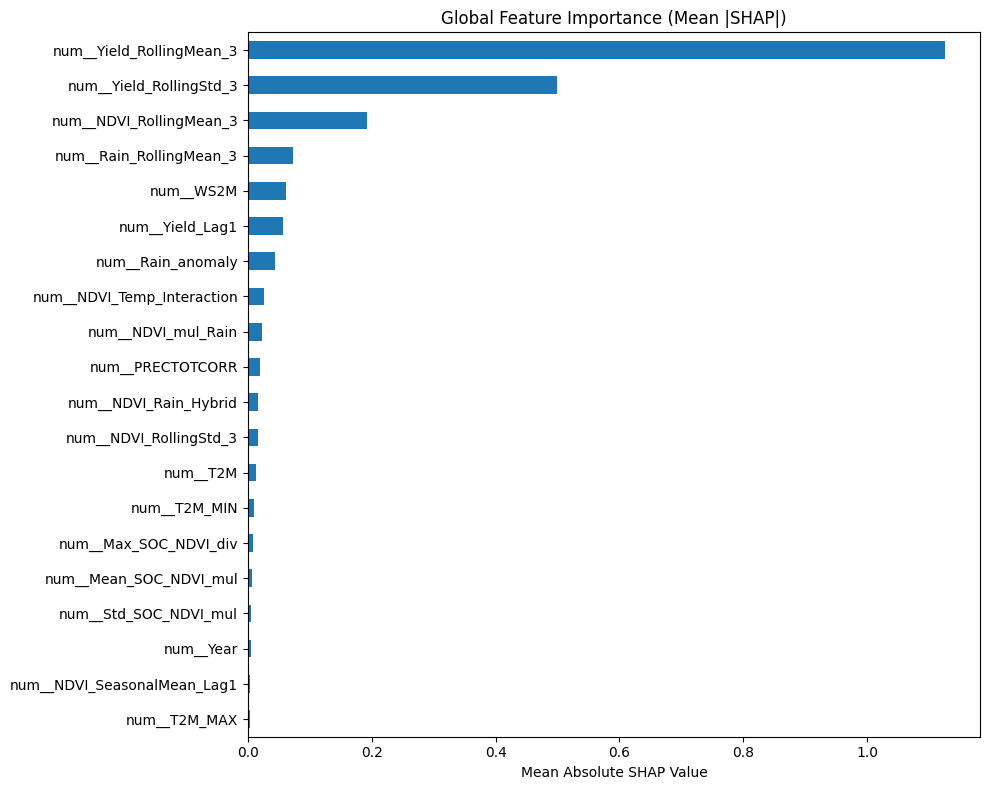

In [2]:
# Mean absolute SHAP value per feature
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
mean_abs_shap.head(20).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Global Feature Importance (Mean |SHAP|)")
plt.xlabel("Mean Absolute SHAP Value")
plt.tight_layout()
plt.show()


elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison


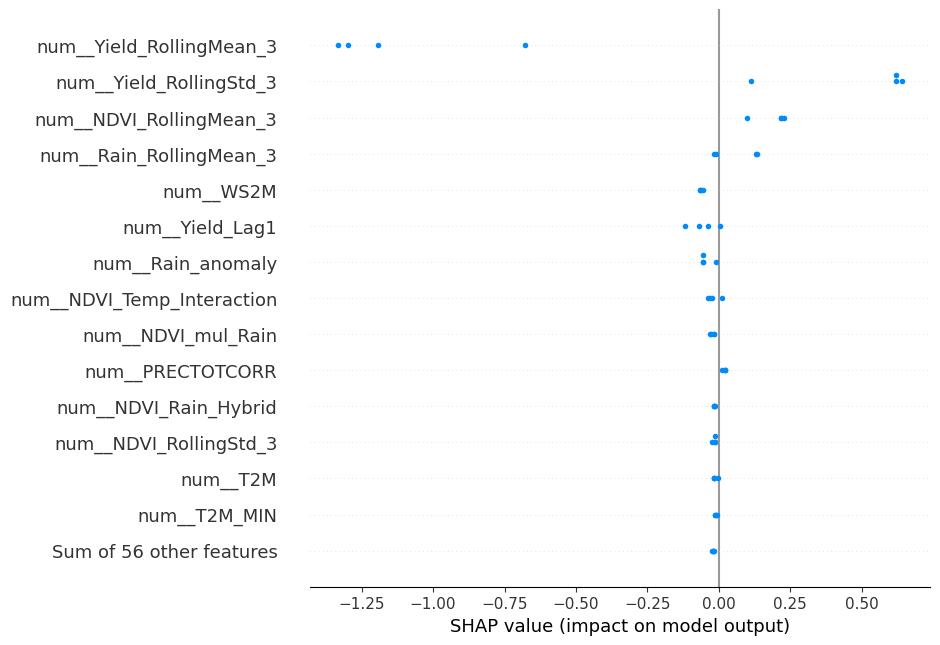

In [13]:
# Convert to numpy
shap_values = shap_df.values
feature_names = shap_df.columns.tolist()

# Create SHAP explanation object
explainer = shap.Explanation(
    values=shap_values,
    feature_names=feature_names
)

# Beeswarm plot
shap.plots.beeswarm(explainer, max_display=15)


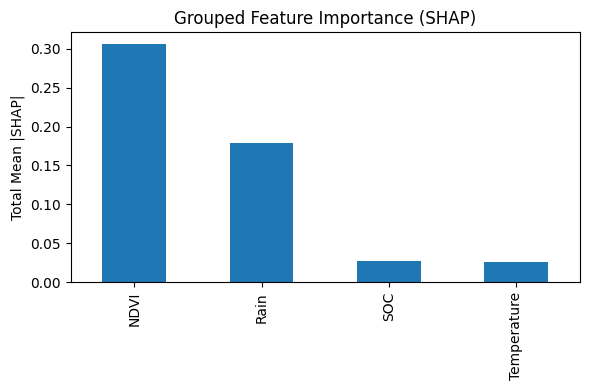

In [5]:
groups = {
    "NDVI": [c for c in shap_df.columns if "NDVI" in c],
    "Rain": [c for c in shap_df.columns if "Rain" in c or "PRECTOT" in c],
    "SOC": [c for c in shap_df.columns if "SOC" in c],
    "Temperature": [c for c in shap_df.columns if "T2M" in c],
}

group_importance = {}

for group, cols in groups.items():
    group_importance[group] = shap_df[cols].abs().mean().sum()

group_series = pd.Series(group_importance).sort_values(ascending=False)

plt.figure(figsize=(6, 4))
group_series.plot(kind="bar")
plt.title("Grouped Feature Importance (SHAP)")
plt.ylabel("Total Mean |SHAP|")
plt.tight_layout()
plt.show()


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load SHAP values
shap_df = pd.read_csv("D:\\Crop_yield_system\\data\\predictions\\shap_values.csv").astype(float)

# Select top features
top_features = shap_df.abs().mean().sort_values(ascending=False).head(20).index
shap_top = shap_df[top_features]

plt.figure(figsize=(10, 6))
plt.imshow(shap_top.T, aspect="auto")
plt.colorbar(label="SHAP Value")
plt.yticks(range(len(top_features)), top_features)
plt.xlabel("Sample Index")
plt.title("SHAP Heatmap of Top Features")

plt.tight_layout()
plt.savefig("figure_shap_heatmap.png", dpi=300, bbox_inches="tight")
plt.close()


In [9]:
import numpy as np

# SHAP correlation matrix
corr_matrix = shap_top.corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(top_features)), top_features, rotation=90)
plt.yticks(range(len(top_features)), top_features)
plt.title("Correlation Heatmap of SHAP Values")

plt.tight_layout()
plt.savefig("figure_shap_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.close()


In [11]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Cluster samples based on SHAP profiles
linked = linkage(shap_top.values, method="ward")

plt.figure(figsize=(10, 4))
dendrogram(linked, no_labels=True)
plt.title("Hierarchical Clustering of SHAP Value Patterns")
plt.xlabel("Sample Index")
plt.ylabel("Distance")

plt.tight_layout()
plt.savefig("figure_shap_clustering.png", dpi=300, bbox_inches="tight")
plt.close()


FileNotFoundError: [Errno 2] No such file or directory: 'paper_figures/fig_baseline_rmse.png'

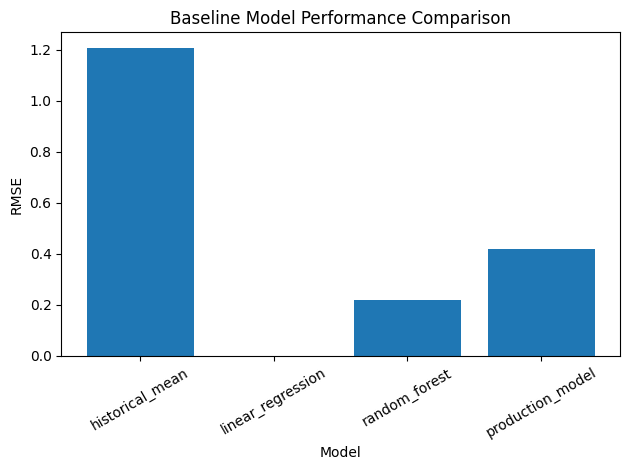

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("D:\\Crop_yield_system\\results\\baselines\\baseline_metrics.csv")

plt.figure()
plt.bar(df["model"], df["rmse"])
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("Baseline Model Performance Comparison")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("paper_figures/fig_baseline_rmse.png", dpi=300)
plt.close()


In [15]:
import joblib
from pathlib import Path

ROOT = Path("D:/Crop_yield_system")
MODELS_DIR = ROOT / "models"

model = joblib.load(MODELS_DIR / "student_lightgbm.joblib")

print("Model expects n_features =", model.n_features_)
import pandas as pd

X = pd.read_csv("D:/Crop_yield_system/models/X_test_features.csv")

print("CSV shape:", X.shape)
print("Column dtypes:")
print(X.dtypes.value_counts())


Model expects n_features = 70
CSV shape: (4, 65)
Column dtypes:
float64    60
object      3
int64       2
Name: count, dtype: int64


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("D:/Crop_yield_system/evaluation/evaluation_predictions.csv")

print(df.head())
print(df.columns)


   index  y_true    y_pred
0    745    2.27  2.909887
1    491    4.67  5.236402
2    250    5.14  4.646353
3    999    3.68  3.842718
Index(['index', 'y_true', 'y_pred'], dtype='object')


FileNotFoundError: [Errno 2] No such file or directory: 'paper_figures/fig_pred_vs_actual.png'

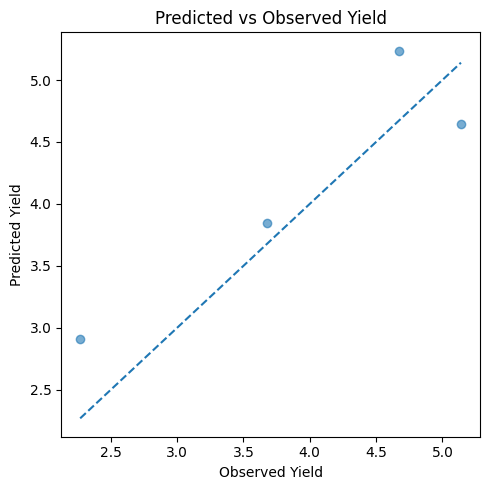

In [17]:
plt.figure(figsize=(5,5))
plt.scatter(df["y_true"], df["y_pred"], alpha=0.6)
plt.plot(
    [df["y_true"].min(), df["y_true"].max()],
    [df["y_true"].min(), df["y_true"].max()],
    linestyle="--"
)
plt.xlabel("Observed Yield")
plt.ylabel("Predicted Yield")
plt.title("Predicted vs Observed Yield")
plt.tight_layout()
plt.savefig("paper_figures/fig_pred_vs_actual.png", dpi=300)
plt.close()
